## ***Install & Import Libraries***

In [1]:
!pip install -q scikit-image cryptography

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from skimage.metrics import peak_signal_noise_ratio as psnr_metric
from skimage.metrics import structural_similarity as ssim_metric
from cryptography.fernet import Fernet

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)


TensorFlow version: 2.20.0
GPU available: True


## ***Settings***


In [2]:
IMG_SIZE = 64
SECRET_BITS = IMG_SIZE * IMG_SIZE
HEADER_BITS = 16          # stores the length of the real message so decoding knows where it ends
BATCH_SIZE = 32
EPOCHS = 10
TRAIN_SUBSET = 8000
TEST_SUBSET = 1000


## ***Loading Dataset from Google Drive***


In [5]:
import os
import shutil
import zipfile
from google.colab import drive

# 1. Mount Google Drive (will ask for permission if not already mounted)
drive.mount('/content/drive')

# 2. Define Paths
ZIP_PATH = "/content/drive/MyDrive/CipherNet/dataset.zip"
EXTRACT_DIR = "/content/ciphernet_dataset"

# 3. Extract the Dataset
if not os.path.exists(ZIP_PATH):
    print(f"\n Error: Could not find {ZIP_PATH}.")
    print("Please check that the file exists in your Drive at that exact path.")
else:
    print(f"\nFound dataset at: {ZIP_PATH}")
    print("Extracting... please wait.")

    # Clear old directory if it exists to ensure a clean extraction
    if os.path.exists(EXTRACT_DIR):
        shutil.rmtree(EXTRACT_DIR)
    os.makedirs(EXTRACT_DIR)

    # Extract the zip
    try:
        with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
            zip_ref.extractall(EXTRACT_DIR)
        print("\n Dataset successfully extracted to:")
        print(EXTRACT_DIR)
    except zipfile.BadZipFile:
        print("\n Error: BadZipFile. The file in Google Drive is incomplete or corrupted.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Found dataset at: /content/drive/MyDrive/CipherNet/dataset.zip
Extracting... please wait.

 Dataset successfully extracted to:
/content/ciphernet_dataset


###  ***Build the Image Pipeline***



In [6]:
import glob
import random

DATA_ROOT = "/content/ciphernet_dataset/dataset"

train_files = glob.glob(os.path.join(DATA_ROOT, "train", "*", "*.jpg"))
test_files = glob.glob(os.path.join(DATA_ROOT, "test", "*", "*.jpg"))

print(f"Found {len(train_files)} training images across all categories")
print(f"Found {len(test_files)} test images across all categories")

random.seed(42)
random.shuffle(train_files)
random.shuffle(test_files)

train_files = train_files[:TRAIN_SUBSET]
test_files = test_files[:TEST_SUBSET]

def load_and_preprocess(path):
    img = tf.io.read_file(path)
    img = tf.io.decode_jpeg(img, channels=3, try_recover_truncated=True, acceptable_fraction=0.5)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0
    return img

def add_random_secret(img):
    # Random bits are used only during TRAINING so the model learns to hide ANY bit pattern.
    # Your real text is only substituted in at the end, for the demo.
    secret = tf.cast(tf.random.uniform((IMG_SIZE, IMG_SIZE, 1), maxval=2, dtype=tf.int32), tf.float32)
    return img, secret

train_ds = tf.data.Dataset.from_tensor_slices(train_files)
train_ds = train_ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.map(add_random_secret, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices(test_files)
test_ds = test_ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.map(add_random_secret, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Using", len(train_files), "training images and", len(test_files), "test images")


Found 14034 training images across all categories
Found 3000 test images across all categories
Using 8000 training images and 1000 test images


## ***Build the Encoder Network***

Takes the cover image + the secret bits (as a same-size binary "image") and outputs a stego image that should look almost identical to the cover.

In [7]:
def build_encoder():
    cover_input = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="cover_image")
    secret_input = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1), name="secret_bits")
    x = layers.Concatenate()([cover_input, secret_input])
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    stego_output = layers.Conv2D(3, 3, padding="same", activation="sigmoid")(x)
    return keras.Model([cover_input, secret_input], stego_output, name="Encoder")

encoder = build_encoder()
encoder.summary()


Model: "Encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ cover_image         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ secret_bits         │ (None, 64, 64, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64, 4) │          0 │ cover_image[0][0… │
│ (Concatenate)       │                   │            │ secret_bits[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │      1,184 │ concatenate[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │     18,496 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     36,928 │ conv2d_1[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     18,464 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64, 3) │        867 │ conv2d_3[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 75,939 (296.64 KB)

 Trainable params: 75,939 (296.64 KB)

 Non-trainable params: 0 (0.00 B)

## ***Build the Decoder Network***

Takes only the stego image and tries to recover the hidden bits.

In [8]:
def build_decoder():
    stego_input = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="stego_image")
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(stego_input)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    secret_output = layers.Conv2D(1, 3, padding="same", activation="sigmoid")(x)
    return keras.Model(stego_input, secret_output, name="Decoder")

decoder = build_decoder()
decoder.summary()


Model: "Decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ stego_image (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,073 (293.25 KB)

 Trainable params: 75,073 (293.25 KB)

 Non-trainable params: 0 (0.00 B)

## ***Connect Them & Train***

We train both networks together. Two things must be true at once, so there are two loss terms:
- The stego image should look like the cover image (`mse` loss).
- The recovered bits should match the secret bits that went in (`binary_crossentropy` loss).

In [9]:
cover_input = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="cover_image")
secret_input = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1), name="secret_bits")

stego_image = encoder([cover_input, secret_input])
recovered_bits = decoder(stego_image)

autoencoder = keras.Model([cover_input, secret_input], [stego_image, recovered_bits], name="StegoAutoencoder")

autoencoder.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=["mse", "binary_crossentropy"],
    loss_weights=[1.0, 1.0],
)

def format_for_training(img, secret):
    return (img, secret), (img, secret)

train_ds2 = train_ds.map(format_for_training)
test_ds2 = test_ds.map(format_for_training)

history = autoencoder.fit(train_ds2, validation_data=test_ds2, epochs=EPOCHS)


Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 22s 49ms/step - Decoder_loss: 0.1393 - Encoder_loss: 0.0328 - loss: 0.1721 - val_Decoder_loss: 0.0014 - val_Encoder_loss: 0.0162 - val_loss: 0.0176
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - Decoder_loss: 9.4678e-04 - Encoder_loss: 0.0104 - loss: 0.0114 - val_Decoder_loss: 6.7257e-04 - val_Encoder_loss: 0.0076 - val_loss: 0.0082
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 12s 46ms/step - Decoder_loss: 5.6993e-04 - Encoder_loss: 0.0060 - loss: 0.0066 - val_Decoder_loss: 5.0600e-04 - val_Encoder_loss: 0.0048 - val_loss: 0.0053
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - Decoder_loss: 4.3310e-04 - Encoder_loss: 0.0039 - loss: 0.0044 - val_Decoder_loss: 3.1439e-04 - val_Encoder_loss: 0.0032 - val_loss: 0.0035
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - Decoder_loss: 0.0272 - Encoder_loss: 0.0312 - loss: 0.0584 - val_Decoder_loss: 0.0011 - val_Encoder_loss: 0.0152 - val_loss: 0.0163
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━

## ***Evaluate: PSNR, SSIM, BER***

- **PSNR** (higher is better) — how close the stego image is to the original, in dB.
- **SSIM** (0 to 1, higher is better) — structural similarity between cover and stego.
- **BER** (0 to 1, lower is better) — fraction of hidden bits that came back wrong.

In [10]:
sample_covers, sample_secrets = next(iter(test_ds))
stego_imgs, recovered = autoencoder.predict([sample_covers, sample_secrets])

def compute_metrics(covers, stegos, secrets, recovered):
    psnr_scores, ssim_scores, ber_scores = [], [], []
    covers = covers.numpy()
    secrets = secrets.numpy()
    for i in range(len(covers)):
        psnr_scores.append(psnr_metric(covers[i], stegos[i], data_range=1.0))
        ssim_scores.append(ssim_metric(covers[i], stegos[i], data_range=1.0, channel_axis=-1))
        true_bits = secrets[i].flatten()
        pred_bits = (recovered[i].flatten() > 0.5).astype("float32")
        ber_scores.append(np.mean(true_bits != pred_bits))
    return np.mean(psnr_scores), np.mean(ssim_scores), np.mean(ber_scores)

avg_psnr, avg_ssim, avg_ber = compute_metrics(sample_covers, stego_imgs, sample_secrets, recovered)
print(f"PSNR: {avg_psnr:.2f} dB   (30+ is generally considered good)")
print(f"SSIM: {avg_ssim:.4f}      (closer to 1.0 = more similar)")
print(f"BER:  {avg_ber:.4f}       (closer to 0.0 = more accurate recovery)")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 965ms/step
PSNR: 23.89 dB   (30+ is generally considered good)
SSIM: 0.7892      (closer to 1.0 = more similar)
BER:  0.0001       (closer to 0.0 = more accurate recovery)


## ***Cover vs. Stego Image***

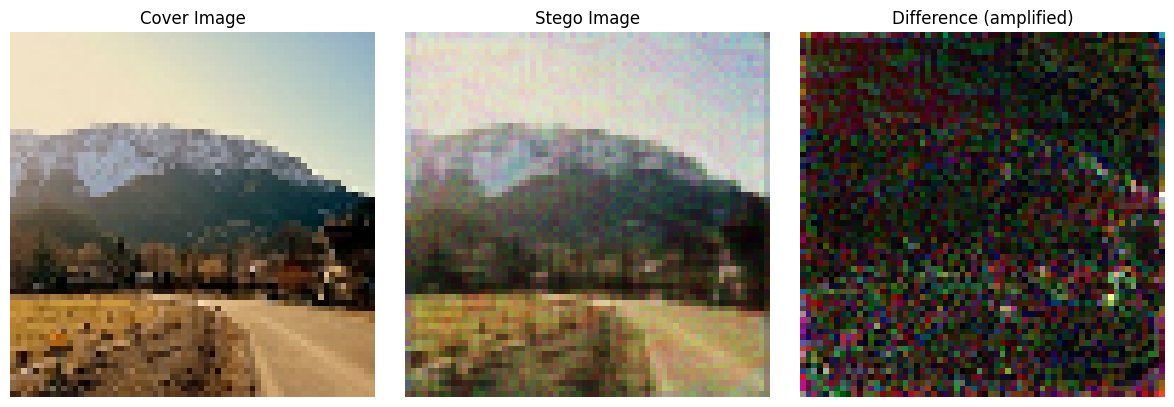

In [13]:
idx = 0
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(sample_covers[idx].numpy()); axes[0].set_title("Cover Image"); axes[0].axis("off")
axes[1].imshow(stego_imgs[idx]); axes[1].set_title("Stego Image"); axes[1].axis("off")
diff = np.abs(sample_covers[idx].numpy() - stego_imgs[idx])
axes[2].imshow(diff / (diff.max() + 1e-8)); axes[2].set_title("Difference (amplified)"); axes[2].axis("off")
plt.tight_layout()
plt.show()


## ***Try It With Real Encrypted Text***

We are using Fernet cipher (real, working symmetric encryption) before converting the ciphertext to bits.

In [14]:
key = Fernet.generate_key()
cipher = Fernet(key)

def int_to_bits(value, num_bits=HEADER_BITS):
    return np.array([int(b) for b in format(value, f"0{num_bits}b")], dtype=np.float32)

def bits_to_int(bits):
    bits = (bits > 0.5).astype(int)
    return int("".join(str(b) for b in bits), 2)

def text_to_bits(text, cipher, capacity_bits=SECRET_BITS):
    encrypted = cipher.encrypt(text.encode())
    payload_bits = np.unpackbits(np.frombuffer(encrypted, dtype=np.uint8)).astype(np.float32)
    max_payload = capacity_bits - HEADER_BITS
    if len(payload_bits) > max_payload:
        raise ValueError(f"Message too long. Max ~{max_payload // 8 - 57} characters for this image size.")
    header = int_to_bits(len(payload_bits))
    full = np.zeros(capacity_bits, dtype=np.float32)
    full[:HEADER_BITS] = header
    full[HEADER_BITS:HEADER_BITS + len(payload_bits)] = payload_bits
    return full.reshape(1, IMG_SIZE, IMG_SIZE, 1)

def bits_to_text(bits_array, cipher):
    flat = bits_array.flatten()
    payload_len = bits_to_int(flat[:HEADER_BITS])
    payload = flat[HEADER_BITS:HEADER_BITS + payload_len]
    payload = (payload > 0.5).astype(np.uint8)
    byte_arr = np.packbits(payload)
    return cipher.decrypt(bytes(byte_arr)).decode()

secret_text = "Hello from CipherNet! This message is hidden inside the image."
secret_bits_img = text_to_bits(secret_text, cipher)

test_cover = sample_covers[0:1]
stego_result = encoder.predict([test_cover, secret_bits_img])
recovered_bits = decoder.predict(stego_result)
recovered_text = bits_to_text(recovered_bits[0], cipher)

print("Original message :", secret_text)
print("Recovered message:", recovered_text)
print("Match:", secret_text == recovered_text)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Original message : Hello from CipherNet! This message is hidden inside the image.
Recovered message: Hello from CipherNet! This message is hidden inside the image.
Match: True


##  ***`Save Everything`***

In [15]:
import pickle

encoder.save("encoder.h5")
decoder.save("decoder.h5")

with open("encryption_key.pkl", "wb") as f:
    pickle.dump(key, f)

print("Saved: encoder.h5, decoder.h5, encryption_key.pkl")


Saved: encoder.h5, decoder.h5, encryption_key.pkl


In [ ]:
from google.colab import files
files.download("encoder.h5")
files.download("decoder.h5")
files.download("encryption_key.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>